**Import Packages**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

**Managing all Directories Paths**

In [ ]:
# Set all path variables
PROJECT_PATH = Path("/content/capstone_project/")
RAW_DIR = PROJECT_PATH / "data" / "raw"
PROCESSED_DIR = PROJECT_PATH / "data" / "processed"

**Loading the Retail Dataset**

In [ ]:
# Reading/loading of the raw Data CSV file
raw_csv = RAW_DIR / "retail_interactions.csv"

In [ ]:
retail_data_df = pd.read_csv(raw_csv)

**Dataset Overview and Understanding**

In [ ]:
# checking the top 5 rows
retail_data_df.head()

,customer_id,age,gender,city_tier,state,income_band,occupation,membership_level,days_since_last_purchase,avg_order_value,...,product_title,product_description,customer_review_text,customer_query,policy_doc_id,policy_text_snippet,image_path,recommended_use_case,style_tags,occasion_tags
0,C100,26,Male,Tier-3,Tamil Nadu,Low,Self-Employed,Platinum,42,3334.08,...,Fastrack Blue Backpack Leather Accessorie,A blue backpack from Fastrack made with leathe...,Loved the blue accessories product. Good quali...,Need a blue backpack for travel under Rs. 4478,POL_WARRANTY,Watches and selected accessories carry a 6-mon...,images/P1000.jpg,Travel,"Blue, Leather, Travel",Travel
1,C101,45,Female,Tier-2,Maharashtra,Low,Teacher,Bronze,23,4151.07,...,Bata Blue Sneakers Mesh Shoes,A blue sneakers from Bata made with mesh. Desi...,Loved the blue shoes product. Good quality and...,Need a blue sneakers for daily wear under Rs. ...,POL_REFUND,Refunds are processed after the returned item ...,images/P1001.jpg,Daily Wear,"Blue, Mesh, Daily Wear",Daily Wear
2,C102,54,Male,Tier-3,Delhi,Low,Engineer,Gold,24,2609.11,...,Nike Grey Sneakers Leather Shoes,A grey sneakers from Nike made with leather. D...,The product was average. The grey look was fin...,Need a grey sneakers for office under Rs. 3262,POL_EXCHANGE,Size exchanges are allowed within 10 days of d...,images/P1002.jpg,Office,"Grey, Leather, Office",Office
3,C103,28,Female,Tier-2,Karnataka,High,Self-Employed,Silver,14,3950.84,...,Puma Brown Backpack Synthetic Accessorie,A brown backpack from Puma made with synthetic...,Not fully satisfied with the accessories item....,Need a brown backpack for travel under Rs. 4315,POL_EXCHANGE,Size exchanges are allowed within 10 days of d...,images/P1003.jpg,Travel,"Brown, Synthetic, Travel",Travel
4,C104,27,Female,Tier-1,Maharashtra,High,Self-Employed,Gold,22,3493.37,...,Wildcraft Grey Cap Fabric Accessorie,A grey cap from Wildcraft made with fabric. De...,Not fully satisfied with the accessories item....,Need a grey cap for sports under Rs. 1818,POL_RETURNS,Returns are allowed within 7 days of delivery ...,images/P1004.jpg,Sports,"Grey, Fabric, Sports",Sports


In [ ]:
# checking the shape of the data
retail_data_df.shape

(1500, 46)

In [ ]:
# Getting the overall data information
retail_data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 46 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               1500 non-null   object 
 1   age                       1500 non-null   int64  
 2   gender                    1500 non-null   object 
 3   city_tier                 1500 non-null   object 
 4   state                     1500 non-null   object 
 5   income_band               1500 non-null   object 
 6   occupation                1500 non-null   object 
 7   membership_level          1500 non-null   object 
 8   days_since_last_purchase  1500 non-null   int64  
 9   avg_order_value           1500 non-null   float64
 10  total_orders              1500 non-null   int64  
 11  preferred_channel         1500 non-null   object 
 12  product_id                1500 non-null   object 
 13  category                  1500 non-null   object 
 14  sub_cate

# Exploratory Data Analysis

- EDA helps us to understand the dataset's structure, distributions, patterns,
relationships, and outliers through statistical analysis and visualizations.
- It help to identify data quality issues, and uncover relationships that guide preprocessing of the data.
- These insights guide data preprocessing, feature engineering, and model development.

Checking Customer level distribution

In [ ]:
# Counting the number of unique customers
unique_cust_count = retail_data_df['customer_id'].nunique()
print(f"Total unique customers: {unique_cust_count}")

In [ ]:
# Segmentation based on the customer's membership level
cust_membership_count = retail_data_df['membership_level'].nunique()
membership_levels =  retail_data_df['membership_level'].value_counts()
print(f"Dataset has  {cust_membership_count} membership levels :: {membership_levels}")

Checking Product level distribution

In [ ]:
# Counting the number of unique products
unique_prod_count = retail_data_df['product_id'].nunique()
print(f"Total unique products: {unique_prod_count}")

In [ ]:
# Counting the overall product categories
categories_count =  retail_data_df['category'].value_counts()
print(f"Total product categories: {categories_count}")

In [ ]:
# Separating the numeric & categorical columns as per data dictionary
numeric_cols = retail_data_df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = retail_data_df.select_dtypes(include=['object']).columns.tolist()
print(f"Total numerical cols are : {numeric_cols}")
print(f"Total categorical cols are : {categorical_cols}")

# Seperate out the list of the Textual cols that may required later to create the Product/Policy store for RAG
text_cols = ["product_title", "product_description", "customer_review_text", "customer_query", "policy_text_snippet"]

# Looking to the distribution of the customer purchase's behavior i.e. how many customers have actually purchased the product.
# This column can be treated as a Target column for the ML Classification to predict Customer's purchase probability
retail_data_df["purchase_flag"].value_counts()

**Data Quality Checks**

1) Checking Missing vaues

In [ ]:
# Checking for Null values
retail_data_df.isnull().sum()

,0
customer_id,0
age,0
gender,0
city_tier,0
state,0
income_band,0
occupation,0
membership_level,0
days_since_last_purchase,0
avg_order_value,0


**Analysis**

Size column is having 270 values which are missing in the dataset.
The available values in the col are S,M,L,XL.
The missing values may have not been recorded, or the Size values may not have been applicable for those features.
This needs to be investigated

 Lets try to check the concentration of the Size col with other features to identify if those Missing values are genuinly not applicable or those not even recorded

In [ ]:
# Checking with the Category feature
retail_data_df[retail_data_df["size"].isna()]["category"].value_counts()

,count
category,
Shoes,92
Apparel,90
Accessories,88


In [ ]:
# Checking with the sub_category feature
retail_data_df[retail_data_df["size"].isna()]["sub_category"].value_counts()

,count
sub_category,
Cap,30
Sneakers,29
Jeans,28
Running,25
Casual,22
Watch,22
Shirt,22
Tshirt,22
Backpack,21


**Analysis**

Above details shows that those missing records belongs to categories ike Accessories(88), Shoes(92), Appare(90) , and Size value does matter for these features. Instead of deleting those records or mentioning them as "Not-Applicable" , we would need to retain those rows and need to update those missing values with "Unknow" i.e. not-recorded during the data collection stage

In [ ]:
retail_data_df['size'] = retail_data_df['size'].fillna('Unknown')

In [ ]:
# Re-checking the Null values
retail_data_df.isnull().sum()

,0
customer_id,0
age,0
gender,0
city_tier,0
state,0
income_band,0
occupation,0
membership_level,0
days_since_last_purchase,0
avg_order_value,0


2) Checking Duplicate Values

In [ ]:
# Checking if the data contains any duplicated rows
retail_data_df.duplicated().sum()

np.int64(0)

3) Possible Data Leakage

We may need to find out possible features those may cause data leakage.
Cols whose values may be identified only after 'purchased_flag' lets say is True.
We may need to ask "Would we require to know these Feature values at the moment we want to predict 'purchase_flag' ?

From the dataset, I would flag out the fetaures **[returned_flag , rating_given]** as the features which may cause the data leakage as those are not required to be known to predict the target and it represents information that occurs only after the purchase.

4) Checking Data Correlation

In [ ]:
# Calculate correlation matrix
corr_matrix = retail_data_df.corr(numeric_only=True)
# Look at correlations with the target variable
target_corr = corr_matrix['purchase_flag'].abs().sort_values(ascending=False)
print(target_corr)

**Data Visualization for Customer Purchase Behavior**

Visualization of Numerical Columns Vs Purchase Flag

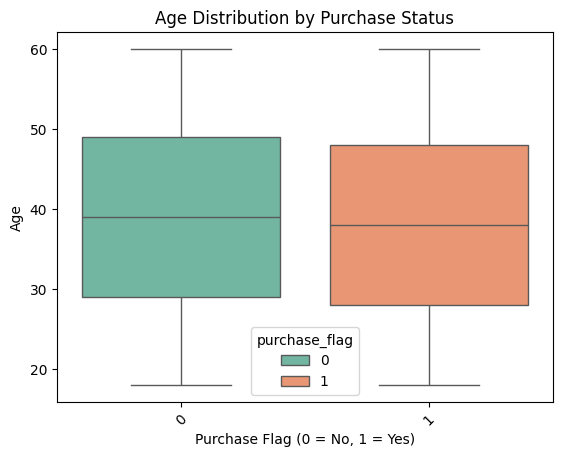

In [ ]:
sns.boxplot(data=retail_data_df, x='purchase_flag', hue='purchase_flag', y='age', palette='Set2')

plt.title('Age Distribution by Purchase Status')
plt.xticks(rotation=45)
plt.xlabel('Purchase Flag (0 = No, 1 = Yes)')
plt.ylabel('Age')
plt.show()

Analysis:

Box for 0 sits slightly higher up on Y-axis than the box for 1, shows that younger customers have a higher purchase behavior.

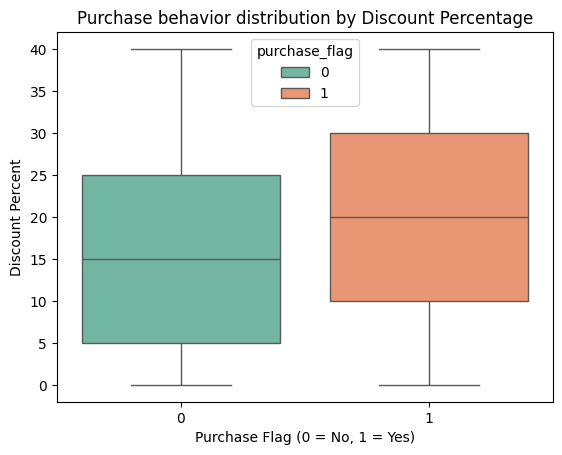

In [ ]:
sns.boxplot(data=retail_data_df, x='purchase_flag', hue='purchase_flag', y='discount_percent', palette='Set2')

plt.title('Purchase behavior distribution by Discount Percentage')
plt.xlabel('Purchase Flag (0 = No, 1 = Yes)')
plt.ylabel('Discount Percent')
plt.show()

Analysis:

Box for 1 sits significantly higher up on Y-axis than the box for 0, shows that more discount on the produts shows strong predictor for the purchase

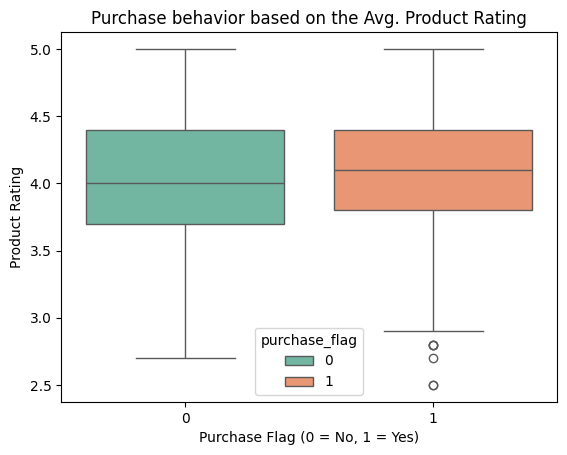

In [ ]:
sns.boxplot(data=retail_data_df, x='purchase_flag', hue='purchase_flag', y='avg_product_rating', palette='Set2')

plt.title('Purchase behavior based on the Avg. Product Rating')
plt.xlabel('Purchase Flag (0 = No, 1 = Yes)')
plt.ylabel('Product Rating')
plt.show()

Analysis:

Plot showing similarity between the purchase flag and the avg. product ratings, although seing few outliers for postive values with lower product ratings.

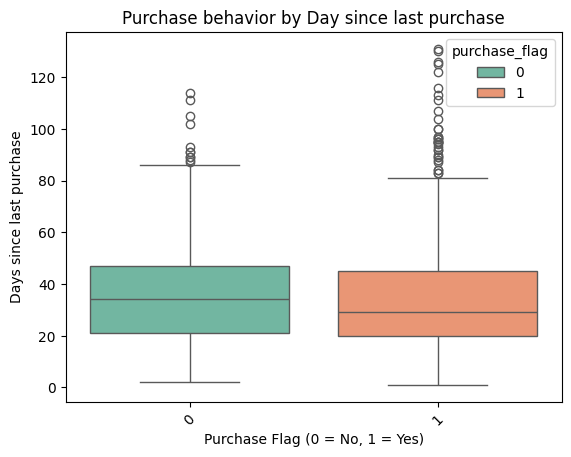

In [ ]:
sns.boxplot(data=retail_data_df, x='purchase_flag', hue='purchase_flag', y='days_since_last_purchase', palette='Set2')

plt.title('Purchase behavior by Day since last purchase')
plt.xticks(rotation=45)
plt.xlabel('Purchase Flag (0 = No, 1 = Yes)')
plt.ylabel('Days since last purchase')
plt.show()

Visualization of Categorical Columns Vs Purchase Flag

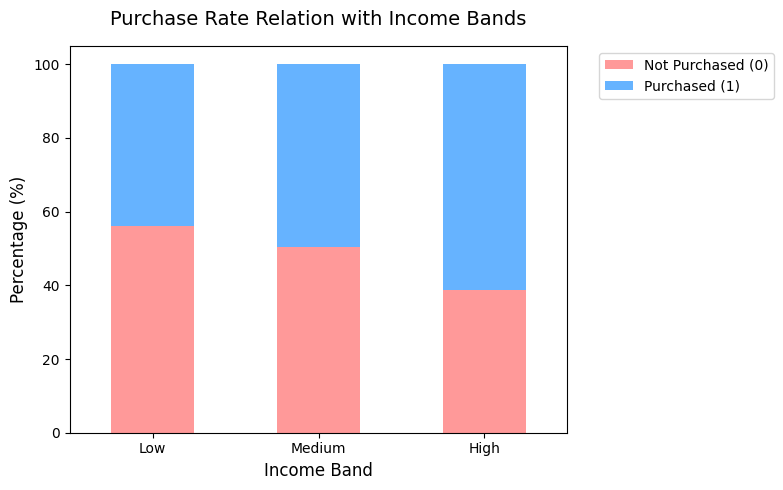

In [ ]:
# Defining the correct logical order for the income bands
income_order = ['Low', 'Medium', 'High']
# Converting 'income_band' into an ordered Categorical type
retail_data_df['income_band'] = pd.Categorical(retail_data_df['income_band'], categories=income_order, ordered=True)

# Creating the percentage cross-tabulation of income-band Vs purchase_flag
pivot_df = pd.crosstab(retail_data_df['income_band'], retail_data_df['purchase_flag'], normalize='index') * 100

# Plotting
fig, ax = plt.subplots(figsize=(8, 5))
pivot_df.plot(kind='bar', stacked=True, color=['#ff9999', '#66b3ff'], ax=ax)
plt.legend(['Not Purchased (0)', 'Purchased (1)'], bbox_to_anchor=(1.05, 1), loc='upper left')

plt.title('Purchase Rate Relation with Income Bands', fontsize=14, pad=15)
plt.xlabel('Income Band', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

Analysis:

1. After scanning the charts shows that the purchase behavior is increasing linearily from lowest income band to the highest. This shows the positive relationship between these two columns.
2. The "Bought" band of the High income people are comparatively higher than the other bands. This helps to identify our primary target demographic.

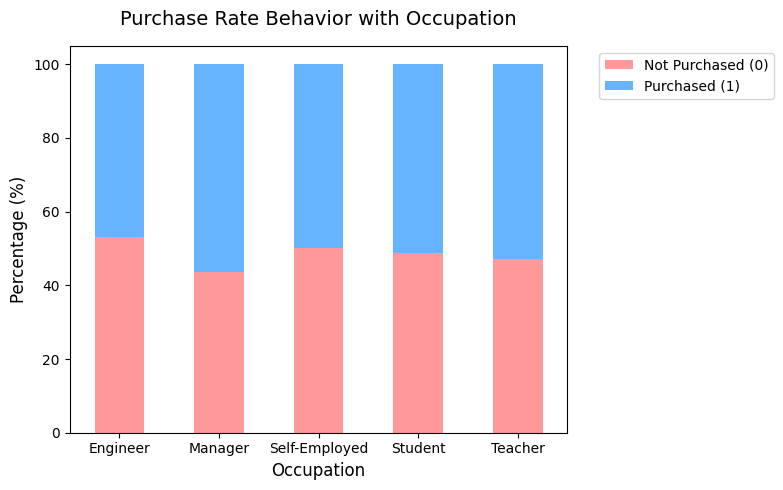

In [ ]:
# Creating the percentage cross-tabulation of occupation Vs purchase_flag
pivot_df = pd.crosstab(retail_data_df['occupation'], retail_data_df['purchase_flag'], normalize='index') * 100

# Plotting
fig, ax = plt.subplots(figsize=(8, 5))
pivot_df.plot(kind='bar', stacked=True, color=['#ff9999', '#66b3ff'], ax=ax)
plt.legend(['Not Purchased (0)', 'Purchased (1)'], bbox_to_anchor=(1.05, 1), loc='upper left')

plt.title('Purchase Rate Behavior with Occupation', fontsize=14, pad=15)
plt.xlabel('Occupation', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

Analysis:

After scanning the charts shows that the purchase behavior is highest for the customers who are designated as Managers. Surprisingly, "Bought" band is almost consistent for other occupation categories

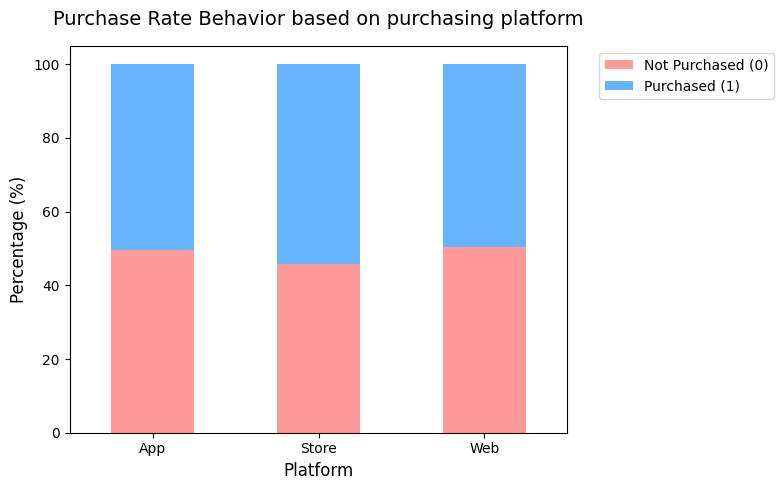

In [ ]:
# Creating the percentage cross-tabulation of preferred_channel Vs purchase_flag
pivot_df = pd.crosstab(retail_data_df['preferred_channel'], retail_data_df['purchase_flag'], normalize='index') * 100

# Plotting
fig, ax = plt.subplots(figsize=(8, 5))
pivot_df.plot(kind='bar', stacked=True, color=['#ff9999', '#66b3ff'], ax=ax)
plt.legend(['Not Purchased (0)', 'Purchased (1)'], bbox_to_anchor=(1.05, 1), loc='upper left')

plt.title('Purchase Rate Behavior based on purchasing platform', fontsize=14, pad=15)
plt.xlabel('Platform', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

Analysis:

Plot shows almost imilar pattern of the purchase behavior based on the purchasing platform

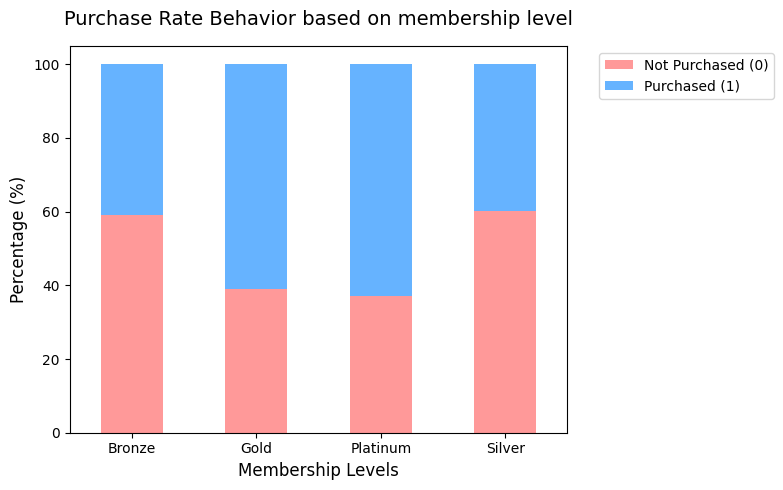

In [ ]:
# Creating the percentage cross-tabulation of membership_level Vs purchase_flag
pivot_df = pd.crosstab(retail_data_df['membership_level'], retail_data_df['purchase_flag'], normalize='index') * 100

# Plotting
fig, ax = plt.subplots(figsize=(8, 5))
pivot_df.plot(kind='bar', stacked=True, color=['#ff9999', '#66b3ff'], ax=ax)
plt.legend(['Not Purchased (0)', 'Purchased (1)'], bbox_to_anchor=(1.05, 1), loc='upper left')

plt.title('Purchase Rate Behavior based on membership level', fontsize=14, pad=15)
plt.xlabel('Membership Levels', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

Analysis:

Plot clearly shows that memberhip level having linear relationship with the purchase where premium category showing stronger purchase behavior

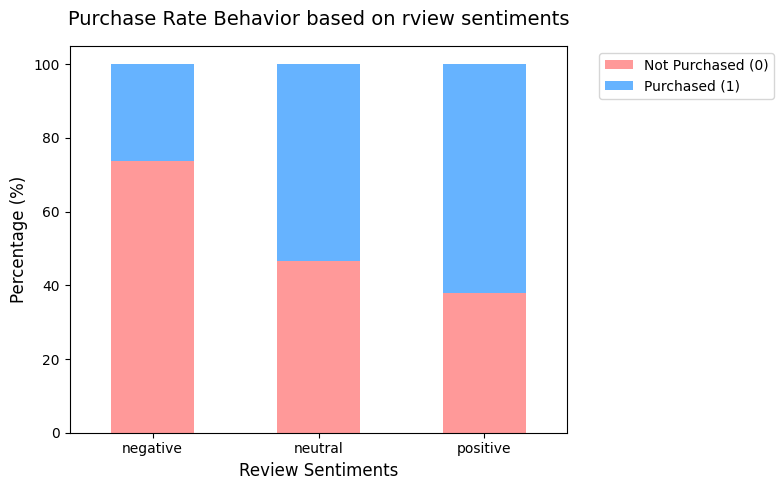

In [ ]:
# Creating the percentage cross-tabulation of review-sentiment Vs purchase_flag
pivot_df = pd.crosstab(retail_data_df['review_sentiment_label'], retail_data_df['purchase_flag'], normalize='index') * 100

# Plotting
fig, ax = plt.subplots(figsize=(8, 5))
pivot_df.plot(kind='bar', stacked=True, color=['#ff9999', '#66b3ff'], ax=ax)
plt.legend(['Not Purchased (0)', 'Purchased (1)'], bbox_to_anchor=(1.05, 1), loc='upper left')

plt.title('Purchase Rate Behavior based on rview sentiments', fontsize=14, pad=15)
plt.xlabel('Review Sentiments', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

Analysis:

Review Sentiments has a linear relationship with the purchase behavior of the product. More positive review for any product has more chances of being bought by the customers

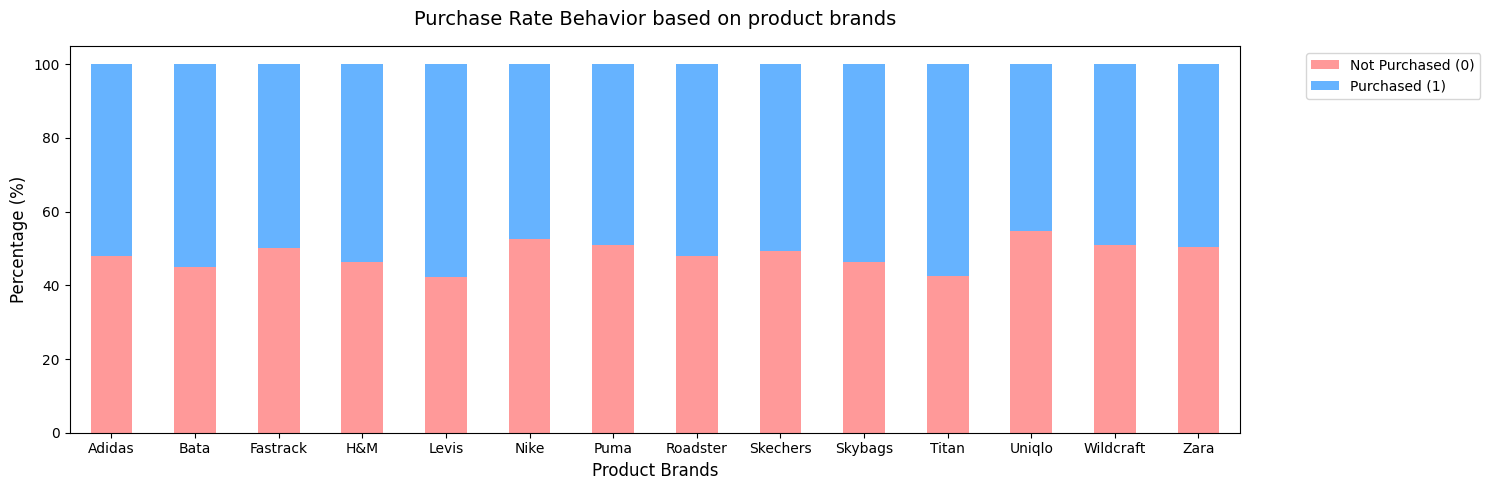

In [ ]:
# Creating the percentage cross-tabulation of product brands Vs purchase_flag
pivot_df = pd.crosstab(retail_data_df['brand'], retail_data_df['purchase_flag'], normalize='index') * 100

# Plotting
fig, ax = plt.subplots(figsize=(15, 5))
pivot_df.plot(kind='bar', stacked=True, color=['#ff9999', '#66b3ff'], ax=ax)
plt.legend(['Not Purchased (0)', 'Purchased (1)'], bbox_to_anchor=(1.05, 1), loc='upper left')

plt.title('Purchase Rate Behavior based on product brands', fontsize=14, pad=15)
plt.xlabel('Product Brands', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

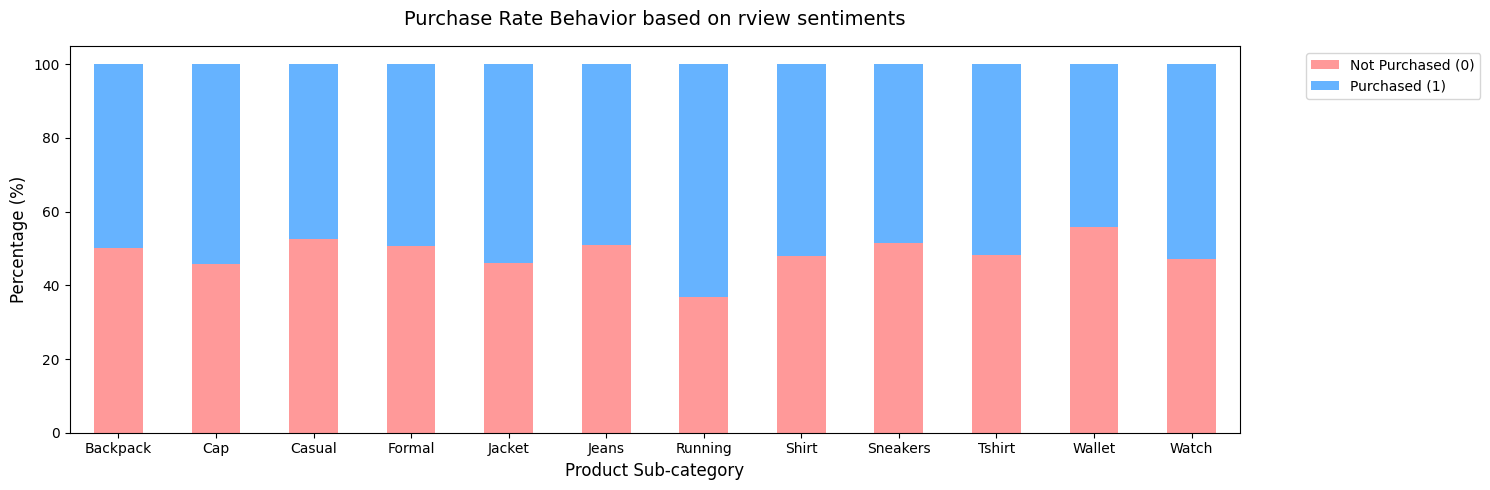

In [ ]:
# Creating the percentage cross-tabulation of category Vs purchase_flag
pivot_df = pd.crosstab(retail_data_df['sub_category'], retail_data_df['purchase_flag'], normalize='index') * 100

# Plotting
fig, ax = plt.subplots(figsize=(15, 5))
pivot_df.plot(kind='bar', stacked=True, color=['#ff9999', '#66b3ff'], ax=ax)
plt.legend(['Not Purchased (0)', 'Purchased (1)'], bbox_to_anchor=(1.05, 1), loc='upper left')

plt.title('Purchase Rate Behavior based on rview sentiments', fontsize=14, pad=15)
plt.xlabel('Product Sub-category', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

Analysis:

Plot showing the nature of product sub-categories impacting the behavior of the customer's purchase possibilities

## Updating the CSV to the Processed folder:

Once we analyzed the data and fill with the missing values, we will store that master dataset into the processed folder to be consumed for Classical ML modeling

In [ ]:
processed_csv = PROCESSED_DIR / "retail_processed.csv"
retail_data_df.to_csv(
    processed_csv,
    index=False
)

# **Conclusion And Outcome**

In this notebook, I have loaded and prepared the raw retail dataset for downstream Machine Learning and RAG components of the Intelligent Retail Assistant.

**Activities Performed :**

*  Loaded and inspected the raw dataset.
*  Performed data quality checks, including missing-value and data-type analysis.
*  Identified numerical and categorical features.
*  Analyzed the relationship between customer/product attributes and the **purchase_flag** target.
*  Saved the processed dataset for use by subsequent notebooks.

**Output:**

Processed dataset: data/processed/...

This processed dataset is used as the input for Notebook 02 (Classical ML) and other downstream components.




